In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
CA1_path <- paste0(indir,"/06_H3K27ac_Allsubclass/CA1/")
CA1_files <- list.files(path = CA1_path, pattern = "\\.tmp$", full.names = TRUE)
CA1_files

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_CT.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L2_3.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L4_Rorb.mm10.tmp"
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L5.mm10.tmp"     
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L6.mm10.tmp"     
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_NP.mm10.tmp"     
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_HC_CA1.mm10.tmp"    
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_HC_CA23.mm10.tmp"   
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_HC_DG.mm10.tmp"     
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_In_CGE.mm10.tmp"    
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_In_Pvalb.mm10.tmp"  
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_In_Sst.mm10.tmp"

In [3]:
merged_CA1 <- NULL

In [4]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27ac_FC_CT.mm10.tmp")

[1] "CT"

In [5]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27ac_FC_L2_3.mm10.tmp")

[1] "L2_3"

In [6]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27ac_HC_DG.mm10.tmp")
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27ac_In_Pvalb.mm10.tmp")

[1] "DG"

[1] "Pvalb"

In [7]:
for (file in CA1_files) {

  base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
  print(base_name)

  tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  if (!is.null(merged_CA1)) {
    if (!identical(merged_CA1[, 1], tmp_data[, 1])) {
      stop(paste("The first column in file", file, "is not identical to the previous files!"))
    }
  }

  colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

  if (is.null(merged_CA1)) {
    merged_CA1 <- tmp_data
  } else {
    merged_CA1 <- cbind(merged_CA1, tmp_data[, -1])
  }
}

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


In [8]:
merged_CA1

hyperDHMR,CT_signal_sum,CT_signal_sum_log10,L2_3_signal_sum,L2_3_signal_sum_log10,L4_Rorb_signal_sum,L4_Rorb_signal_sum_log10,L5_signal_sum,L5_signal_sum_log10,L6_signal_sum,⋯,CA23_signal_sum,CA23_signal_sum_log10,DG_signal_sum,DG_signal_sum_log10,CGE_signal_sum,CGE_signal_sum_log10,Pvalb_signal_sum,Pvalb_signal_sum_log10,Sst_signal_sum,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,0.0000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:3868330-3869330,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,0.0000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:4000851-4001851,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,0.0000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:4017553-4018553,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,308.1618,⋯,0.0000,0.000000,0.00000,0.000000,0.0000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:4168027-4169027,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,0.0000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:4249638-4250638,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,237.44120,2.377381,345.1138,2.539219,0.0000,0.000000,0.00000,0.000000
chr1:4454449-4455449,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,0.0000,0.000000,518.1757,2.715314,0.00000,0.000000
chr1:4794017-4795017,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,0.0000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:5336791-5337791,1335.0746,3.125831,2.629512,0.5598482,2.714652,0.5699181,0.000000,0.0000000,164.9754,⋯,0.0000,0.000000,0.00000,0.000000,0.0000,0.000000,0.0000,0.000000,0.00000,0.000000


In [9]:
merged_CA1 <- merged_CA1[, c(1, grep("signal_sum_log10", colnames(merged_CA1)))]

merged_CA1

hyperDHMR,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.000000,0.0000000,0.0000000,0.0000000,2.490186,0,2.208759,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,2.377381,2.539219,0.000000,0.000000
chr1:4454449-4455449,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,2.715314,0.000000
chr1:4794017-4795017,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,2.849732,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,3.125831,0.5598482,0.5699181,0.0000000,2.220044,0,2.626956,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [11]:
merged_CA1 <- merged_CA1 %>% column_to_rownames("hyperDHMR")
merged_CA1

,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.000000,0.0000000,0.0000000,0.0000000,2.490186,0,2.208759,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,2.377381,2.539219,0.000000,0.000000
chr1:4454449-4455449,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,2.715314,0.000000
chr1:4794017-4795017,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,2.849732,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,3.125831,0.5598482,0.5699181,0.0000000,2.220044,0,2.626956,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
colnames(merged_CA1) <- gsub("_signal_sum_log10$","",colnames(merged_CA1))
merged_CA1

,CT,L2_3,L4_Rorb,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.000000,0.0000000,0.0000000,0.0000000,2.490186,0,2.208759,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,2.377381,2.539219,0.000000,0.000000
chr1:4454449-4455449,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,2.715314,0.000000
chr1:4794017-4795017,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,2.849732,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,3.125831,0.5598482,0.5699181,0.0000000,2.220044,0,2.626956,0.000000,0.000000,0.000000,0.000000,0.000000


In [13]:
colnames(merged_CA1)[which(colnames(merged_CA1) %in% "L4_Rorb")] <- "L4"

In [14]:
merged_CA1

,CT,L2_3,L4,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.000000,0.0000000,0.0000000,0.0000000,2.490186,0,2.208759,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,2.377381,2.539219,0.000000,0.000000
chr1:4454449-4455449,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,2.715314,0.000000
chr1:4794017-4795017,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0,2.849732,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,3.125831,0.5598482,0.5699181,0.0000000,2.220044,0,2.626956,0.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
merged_CA1$merge_L5 <- (merged_CA1$L5+merged_CA1$L6)/2
merged_CA1 <- merged_CA1 %>% dplyr::select(-c(L5,L6))
colnames(merged_CA1)[which(colnames(merged_CA1) == "merge_L5")] <- "L5"
merged_CA1

,CT,L2_3,L4,NP,CA1,CA23,DG,CGE,Pvalb,Sst,L5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.000000,0.0000000,0.0000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:3868330-3869330,0.000000,0.0000000,0.0000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:4000851-4001851,0.000000,0.0000000,0.0000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:4017553-4018553,0.000000,0.0000000,0.0000000,0,2.208759,0.000000,0.000000,0.000000,0.000000,0.000000,1.2450929
chr1:4168027-4169027,0.000000,0.0000000,0.0000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:4249638-4250638,0.000000,0.0000000,0.0000000,0,0.000000,0.000000,2.377381,2.539219,0.000000,0.000000,0.0000000
chr1:4454449-4455449,0.000000,0.0000000,0.0000000,0,0.000000,0.000000,0.000000,0.000000,2.715314,0.000000,0.0000000
chr1:4794017-4795017,0.000000,0.0000000,0.0000000,0,2.849732,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:5336791-5337791,3.125831,0.5598482,0.5699181,0,2.626956,0.000000,0.000000,0.000000,0.000000,0.000000,1.1100219


In [16]:
# celltype_order <- c("L2_3","L4","L5","L6","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order <- c("L2_3","L4","L5","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order

[1] "L2_3"  "L4"    "L5"    "CA1"   "CA23"  "NP"    "CT"    "DG"    "CGE"  
[10] "Pvalb" "Sst"

In [17]:
merged_CA1 <- merged_CA1[,celltype_order]
merged_CA1

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.0000000,0.0000000,1.2450929,2.208759,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,2.377381,2.539219,0.000000,0.000000
chr1:4454449-4455449,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,2.715314,0.000000
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,2.849732,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,0.5598482,0.5699181,1.1100219,2.626956,0.000000,0,3.125831,0.000000,0.000000,0.000000,0.000000


In [18]:
colMeans(merged_CA1) %>% data.frame() %>% t()

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
.,0.779061,0.5401989,0.4866781,0.8014725,0.5230038,0.1923897,0.4802709,0.6672534,0.4277133,0.3166173,0.3732274


In [19]:
process_files <- function(input_path, pattern = "\\.tmp$", celltype_order) {
  files <- list.files(path = input_path, pattern = pattern, full.names = TRUE)
  merged_data <- NULL

  for (file in files) {
    base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
    print(base_name)

    tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

    if (!is.null(merged_data)) {
      if (!identical(merged_data[, 1], tmp_data[, 1])) {
        stop(paste("The first column in file", file, "is not identical to the previous files!"))
      }
    }

    colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

    if (is.null(merged_data)) {
      merged_data <- tmp_data
    } else {
      merged_data <- cbind(merged_data, tmp_data[, -1])
    }
  }

  merged_data <- merged_data[, c(1, grep("signal_sum_log10", colnames(merged_data)))]
  merged_data <- merged_data %>% column_to_rownames("hyperDHMR")
  colnames(merged_data) <- gsub("_signal_sum_log10$", "", colnames(merged_data))

  colnames(merged_data)[which(colnames(merged_data) %in% "L4_Rorb")] <- "L4"

  merged_data$merge_L5 <- (merged_data$L5+merged_data$L6)/2
  merged_data <- merged_data %>% dplyr::select(-c(L5,L6))
  colnames(merged_data)[which(colnames(merged_data) == "merge_L5")] <- "L5"

  celltype_order <- c("L2_3", "L4", "L5", "CA1", "CA23", "NP", "CT", "DG", "CGE", "Pvalb", "Sst")

  merged_data <- merged_data[, celltype_order]
  
  return(merged_data)
}

In [ ]:
H3K27ac_path <- paste0(indir,"/06_H3K27ac_Allsubclass/")

In [21]:
subdirs <- list.dirs(path = H3K27ac_path, full.names = TRUE, recursive = FALSE)
subdirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//CA1"  
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//CA23" 
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//CT"   
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//DG"   
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//L2_3" 
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//L4_5" 
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//L5"   
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//Lamp5"
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//NP"   
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//Pvalb"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//Sncg" 
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/06_H3K27ac_Allsubclass//Sst"

In [22]:
basename(subdirs)

[1] "CA1"   "CA23"  "CT"    "DG"    "L2_3"  "L4_5"  "L5"    "Lamp5" "NP"   
[10] "Pvalb" "Sncg"  "Sst"

In [ ]:
L2_3 <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/L2_3'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L2_3

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:40205252-40206252,2.422483,0.000000,0.0000000,0.000000,0.000000,3.028136,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:63801436-63802436,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:95910578-95911578,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:121992418-121993418,2.916099,0.000000,1.3259621,0.000000,0.000000,0.000000,2.472889,0.000000,0.000000,0.000000,0.000000
chr1:123860055-123861055,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:127035082-127036082,2.167565,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,2.200470,0.000000,0.000000,0.000000
chr1:165699424-165700424,2.827250,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:184865166-184866166,2.473986,2.626009,2.3205440,2.179301,0.000000,0.000000,2.376344,2.377381,0.000000,2.539185,0.000000
chr2:10595247-10596247,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [24]:
L2_3_mean <- colMeans(L2_3) %>% data.frame() %>% t()
rownames(L2_3_mean) <- "L2_3"
L2_3_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.041753,0.593254,0.5480141,0.4010214,0.2791839,0.2087497,0.3552743,0.4517152,0.2959302,0.2738052,0.2360508


In [ ]:
L4_5 <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/L4_5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L4_5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3989606-3990606,1.634197,2.191546,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7536517-7537517,2.494781,0.000000,1.0887981,0.000000,0.000000,0.000000,0.000000,2.339915,2.093026,0.000000,0.000000
chr1:9780815-9781815,1.763222,0.000000,2.2425169,2.029619,2.643218,0.000000,0.000000,2.377381,0.000000,0.000000,0.000000
chr1:14839073-14840073,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:14914779-14915779,0.000000,0.000000,0.0000000,2.482406,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:17756423-17757423,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,2.889622,2.667415,3.085682,1.906977,0.000000
chr1:22023298-22024298,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:23137109-23138109,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:26269966-26270966,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [26]:
L4_5_mean <- colMeans(L4_5) %>% data.frame() %>% t()
rownames(L4_5_mean) <- "L4_5"
L4_5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L4_5,1.089976,1.065824,0.7965455,0.4468276,0.3972659,0.2323712,0.5806932,0.5270874,0.4315559,0.328096,0.3599608


In [ ]:
L5 <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/L5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4185672-4186672,0.000000,1.872724,1.0492375,0.0000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0000000,0.000000
chr1:9994550-9995550,2.433378,2.822549,2.8881369,0.0000000,0.000000,0.000000,3.034120,2.280926,0.00000,0.0000000,0.000000
chr1:20083023-20084023,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,2.346126,0.000000,0.00000,0.0000000,0.000000
chr1:22220457-22221457,0.000000,0.000000,1.0605603,0.0000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0000000,0.000000
chr1:25591789-25592789,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0000000,0.000000
chr1:26496284-26497284,0.000000,1.420562,1.5082201,0.0000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0000000,0.000000
chr1:27086331-27087331,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0000000,0.000000
chr1:27631906-27632906,0.000000,0.000000,1.3259620,0.0000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.7187181,0.000000
chr1:27648468-27649468,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0000000,0.000000


In [28]:
L5_mean <- colMeans(L5) %>% data.frame() %>% t()
rownames(L5_mean) <- "L5"
L5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L5,1.081652,0.807125,0.8760408,0.5331955,0.4484697,0.3124657,0.7861217,0.5290742,0.4537224,0.3598409,0.4468552


In [ ]:
CA1 <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/CA1'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA1

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.0000000,0.0000000,1.2450929,2.208759,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,2.377381,2.539219,0.000000,0.000000
chr1:4454449-4455449,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,2.715314,0.000000
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,2.849732,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,0.5598482,0.5699181,1.1100219,2.626956,0.000000,0,3.125831,0.000000,0.000000,0.000000,0.000000


In [30]:
CA1_mean <- colMeans(CA1) %>% data.frame() %>% t()
rownames(CA1_mean) <- "CA1"
CA1_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA1,0.779061,0.5401989,0.4866781,0.8014725,0.5230038,0.1923897,0.4802709,0.6672534,0.4277133,0.3166173,0.3732274


In [ ]:
CA23 <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/CA23'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA23

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3151305-3152305,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3776523-3777523,0.0000000,0.000000,1.1034680,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.738005,0.000000
chr1:4031436-4032436,0.0000000,0.000000,0.0000000,0.000000,3.283095,0.000000,2.773188,0.000000,0.000000,0.000000,0.000000
chr1:4057009-4058009,0.0000000,0.000000,0.0000000,0.000000,2.485687,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4065207-4066207,0.0000000,0.000000,0.2046992,0.000000,2.140330,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4072107-4073107,0.0000000,0.000000,0.0000000,0.000000,3.130455,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4118129-4119129,0.7190348,2.128140,0.0000000,0.000000,0.000000,3.051307,0.000000,2.377381,2.566938,0.000000,0.000000
chr1:4149321-4150321,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4342915-4343915,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [32]:
CA23_mean <- colMeans(CA23) %>% data.frame() %>% t()
rownames(CA23_mean) <- "CA23"
CA23_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA23,0.80859,0.5978869,0.5642866,0.6065764,0.6900183,0.2679759,0.5786088,0.7332516,0.5231936,0.4040822,0.419479


In [ ]:
NP <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/NP'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

NP

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4035689-4036689,0.000000,0.000000,1.3579143,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:4933311-4934311,2.612820,0.000000,1.0920032,0.000000,2.362127,2.731156,1.983812,2.5091622,0.000000,0.000000,0.000000
chr1:6077804-6078804,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,2.565202,0.000000,0.000000
chr1:6367459-6368459,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:7734392-7735392,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:9367457-9368457,0.000000,0.000000,1.2813848,2.611633,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:9905254-9906254,1.512605,2.464142,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,2.566938,0.000000,2.643321
chr1:10079108-10080108,1.673597,0.000000,0.0000000,1.881136,0.000000,0.000000,0.000000,0.0000000,0.000000,2.193321,0.000000
chr1:10298443-10299443,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000


In [34]:
NP_mean <- colMeans(NP) %>% data.frame() %>% t()
rownames(NP_mean) <- "NP"
NP_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
NP,1.070099,0.8311262,0.7814328,0.7011704,0.6395102,0.5140512,0.8691049,0.82901,0.7049204,0.583254,0.6279805


In [ ]:
CT <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/CT'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CT

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3908393-3909393,2.1675652,1.940844,1.120024,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5417353-5418353,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.847887,0.000000,0.000000,0.000000,0.000000
chr1:5957907-5958907,0.0000000,0.000000,2.311933,2.873128,2.180613,0.000000,2.099177,0.000000,0.000000,0.000000,0.000000
chr1:9594969-9595969,0.0000000,0.000000,0.000000,0.000000,2.381586,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:11620744-11621744,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:11728492-11729492,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:20849555-20850555,0.0000000,0.000000,0.000000,2.591686,0.000000,0.000000,1.974368,0.000000,0.000000,1.700202,0.000000
chr1:20922610-20923610,2.6441547,0.000000,2.533845,0.000000,2.982291,0.000000,2.773188,3.312784,0.000000,3.135470,3.264151
chr1:23933700-23934700,2.3426703,3.142544,2.959792,3.244285,0.000000,0.000000,3.256995,1.393473,0.000000,2.851766,0.000000


In [36]:
CT_mean <- colMeans(CT) %>% data.frame() %>% t()
rownames(CT_mean) <- "CT"
CT_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CT,0.9713144,0.7854571,0.798585,0.5504505,0.5822151,0.3911207,1.233183,0.6728932,0.5887346,0.4343399,0.5180606


In [ ]:
DG <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/DG'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

DG

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:5012521-5013521,2.101541,2.480910,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,1.095743,0.000000
chr1:6862606-6863606,0.000000,0.000000,1.315532,0.000000,0.000000,0,0.000000,3.108770,0.000000,0.000000,0.000000
chr1:7358520-7359520,2.293920,2.480910,0.000000,0.000000,0.000000,0,0.000000,2.841565,2.566938,0.000000,0.000000
chr1:13910825-13911825,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:16814367-16815367,3.024331,0.000000,1.189952,3.230960,2.583403,0,3.216764,2.843786,0.000000,0.000000,0.000000
chr1:17029988-17030988,0.000000,2.341196,0.000000,0.000000,0.000000,0,2.467664,3.165715,0.000000,0.000000,0.000000
chr1:17078363-17079363,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:19954555-19955555,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:27743954-27744954,2.467115,2.500379,0.000000,0.000000,2.982291,0,0.000000,2.276584,0.000000,0.000000,0.000000


In [38]:
DG_mean <- colMeans(DG) %>% data.frame() %>% t()
rownames(DG_mean) <- "DG"
DG_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
DG,0.9568115,0.7154109,0.6565983,0.7445577,0.722832,0.3215,0.6983876,1.184771,0.639058,0.5068898,0.5073583


In [ ]:
Lamp5 <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/Lamp5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Lamp5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3033026-3034026,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3116806-3117806,0.000000,3.255688,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.135470,0.000000
chr1:3235621-3236621,0.000000,2.876076,0.9365679,2.575984,0.000000,0.000000,2.228348,2.572067,2.531299,2.684562,1.861122
chr1:3290843-3291843,2.563383,0.000000,0.0000000,0.000000,0.000000,0.000000,3.031377,0.000000,2.267085,0.000000,0.000000
chr1:3510333-3511333,1.808889,2.547405,2.0530856,2.248511,0.000000,3.918205,2.958192,0.000000,2.132454,0.000000,3.329973
chr1:3802417-3803417,1.600519,2.641534,2.6783108,0.000000,0.000000,0.000000,1.901786,2.537885,2.236671,2.407300,0.000000
chr1:3889972-3890972,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4330502-4331502,0.000000,0.000000,1.0255171,0.000000,0.000000,0.000000,0.000000,0.000000,2.464878,0.000000,0.000000
chr1:4344260-4345260,0.000000,0.000000,0.0000000,2.704849,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [40]:
Lamp5_mean <- colMeans(Lamp5) %>% data.frame() %>% t()
rownames(Lamp5_mean) <- "Lamp5"
Lamp5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Lamp5,0.7256541,0.5155231,0.4976139,0.4560863,0.4309425,0.2236334,0.4980492,0.5620857,0.6443252,0.3784284,0.4257886


In [ ]:
Sncg <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/Sncg'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sncg

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3239626-3240626,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3597956-3598956,1.8484099,0.000000,1.3002294,0.000000,0.000000,0.000000,0.000000,0.000000,2.705235,2.015579,0.000000
chr1:3845937-3846937,0.0000000,0.000000,0.5895106,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7206724-7207724,0.0000000,3.178730,0.0000000,2.335215,2.612310,0.000000,2.438681,0.000000,0.000000,3.004344,0.000000
chr1:7289662-7290662,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7546590-7547590,2.0014615,0.000000,0.0000000,0.000000,0.000000,0.000000,2.472889,0.000000,3.264966,0.000000,0.000000
chr1:7550117-7551117,2.1675652,2.605057,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7583286-7584286,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7777255-7778255,0.0000000,0.000000,1.3579143,0.000000,0.000000,0.000000,0.000000,0.000000,2.867380,0.000000,0.000000


In [42]:
Sncg_mean <- colMeans(Sncg) %>% data.frame() %>% t()
rownames(Sncg_mean) <- "Sncg"
Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sncg,0.9256187,0.709991,0.6519431,0.6131652,0.5403252,0.3349325,0.6818567,0.6954852,0.7308227,0.5068628,0.5713809


In [43]:
rownames(Lamp5_mean) <- "CGE"
rownames(Sncg_mean) <- "CGE"
Lamp5_mean;Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,0.7256541,0.5155231,0.4976139,0.4560863,0.4309425,0.2236334,0.4980492,0.5620857,0.6443252,0.3784284,0.4257886


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,0.9256187,0.709991,0.6519431,0.6131652,0.5403252,0.3349325,0.6818567,0.6954852,0.7308227,0.5068628,0.5713809


In [44]:
identical(rownames(Lamp5_mean),rownames(Sncg_mean))
identical(colnames(Lamp5_mean),colnames(Sncg_mean))

[1] TRUE

[1] TRUE

In [45]:
CGE_mean <- (Lamp5_mean+Sncg_mean)/2
CGE_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,0.8256364,0.612757,0.5747785,0.5346258,0.4856339,0.279283,0.5899529,0.6287855,0.6875739,0.4426456,0.4985848


In [ ]:
Pvalb <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/Pvalb'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Pvalb

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3168678-3169678,1.9056321,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:3188267-3189267,2.1675652,0.000000,0.000000,0.000000,2.459745,0,0.000000,0.000000,0.000000,0.000000,2.7036730
chr1:3189154-3190154,1.4967281,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:3229735-3230735,0.0000000,0.000000,0.000000,0.000000,0.000000,0,1.055499,0.000000,2.551508,2.738006,0.0000000
chr1:3257828-3258828,2.4319714,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:3275051-3276051,1.9462468,0.000000,2.323557,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:3277592-3278592,2.1675652,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:3343546-3344546,0.0000000,2.460528,0.000000,0.000000,0.000000,0,0.000000,0.000000,2.474629,0.000000,0.0000000
chr1:3345473-3346473,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,1.1649470


In [47]:
Pvalb_mean <- colMeans(Pvalb) %>% data.frame() %>% t()
rownames(Pvalb_mean) <- "Pvalb"
Pvalb_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Pvalb,0.8570132,0.622385,0.5943746,0.5241147,0.4843463,0.2661112,0.5929884,0.6414698,0.6329172,0.5989475,0.5506671


In [ ]:
Sst <- process_files(paste0(indir,'/06_H3K27ac_Allsubclass/Sst'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sst

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3074178-3075178,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3083989-3084989,1.859948,2.781222,2.6274961,0.000000,2.882502,0.000000,2.773188,0.000000,0.000000,3.201527,2.824695
chr1:3091016-3092016,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.305089
chr1:3096626-3097626,0.000000,0.000000,1.3093062,0.000000,0.000000,0.000000,0.000000,0.000000,2.851029,0.000000,3.276842
chr1:3098325-3099325,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.357934
chr1:3104126-3105126,0.000000,0.000000,1.1702355,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3105267-3106267,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3133078-3134078,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.367487,2.765713,0.000000
chr1:3135638-3136638,2.150857,0.000000,0.0000000,2.240439,0.000000,0.000000,2.614245,0.000000,1.376785,0.000000,2.651217


In [49]:
Sst_mean <- colMeans(Sst) %>% data.frame() %>% t()
rownames(Sst_mean) <- "Sst"
Sst_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sst,0.8184723,0.59408,0.5490092,0.5170638,0.4675898,0.2520704,0.5706409,0.63931,0.5883838,0.4339588,0.5694589


In [50]:
all <- rbind(L2_3_mean,L4_5_mean,L5_mean,CA1_mean,CA23_mean,NP_mean,CT_mean,DG_mean,CGE_mean,Pvalb_mean,Sst_mean)

In [51]:
head(all);dim(all);all

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.041753,0.5932540,0.5480141,0.4010214,0.2791839,0.2087497,0.3552743,0.4517152,0.2959302,0.2738052,0.2360508
L4_5,1.089976,1.0658243,0.7965455,0.4468276,0.3972659,0.2323712,0.5806932,0.5270874,0.4315559,0.3280960,0.3599608
L5,1.081652,0.8071250,0.8760408,0.5331955,0.4484697,0.3124657,0.7861217,0.5290742,0.4537224,0.3598409,0.4468552
CA1,0.779061,0.5401989,0.4866781,0.8014725,0.5230038,0.1923897,0.4802709,0.6672534,0.4277133,0.3166173,0.3732274
CA23,0.808590,0.5978869,0.5642866,0.6065764,0.6900183,0.2679759,0.5786088,0.7332516,0.5231936,0.4040822,0.4194790
NP,1.070099,0.8311262,0.7814328,0.7011704,0.6395102,0.5140512,0.8691049,0.8290100,0.7049204,0.5832540,0.6279805


[1] 11 11

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.0417532,0.5932540,0.5480141,0.4010214,0.2791839,0.2087497,0.3552743,0.4517152,0.2959302,0.2738052,0.2360508
L4_5,1.0899757,1.0658243,0.7965455,0.4468276,0.3972659,0.2323712,0.5806932,0.5270874,0.4315559,0.3280960,0.3599608
L5,1.0816515,0.8071250,0.8760408,0.5331955,0.4484697,0.3124657,0.7861217,0.5290742,0.4537224,0.3598409,0.4468552
CA1,0.7790610,0.5401989,0.4866781,0.8014725,0.5230038,0.1923897,0.4802709,0.6672534,0.4277133,0.3166173,0.3732274
CA23,0.8085900,0.5978869,0.5642866,0.6065764,0.6900183,0.2679759,0.5786088,0.7332516,0.5231936,0.4040822,0.4194790
NP,1.0700989,0.8311262,0.7814328,0.7011704,0.6395102,0.5140512,0.8691049,0.8290100,0.7049204,0.5832540,0.6279805
CT,0.9713144,0.7854571,0.7985850,0.5504505,0.5822151,0.3911207,1.2331829,0.6728932,0.5887346,0.4343399,0.5180606
DG,0.9568115,0.7154109,0.6565983,0.7445577,0.7228320,0.3215000,0.6983876,1.1847708,0.6390580,0.5068898,0.5073583
CGE,0.8256364,0.6127570,0.5747785,0.5346258,0.4856339,0.2792830,0.5899529,0.6287855,0.6875739,0.4426456,0.4985848
Pvalb,0.8570132,0.6223850,0.5943746,0.5241147,0.4843463,0.2661112,0.5929884,0.6414698,0.6329172,0.5989475,0.5506671


In [52]:
heatmap_matrix <- as.matrix(all)

In [53]:
heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.0417532,0.5932540,0.5480141,0.4010214,0.2791839,0.2087497,0.3552743,0.4517152,0.2959302,0.2738052,0.2360508
L4_5,1.0899757,1.0658243,0.7965455,0.4468276,0.3972659,0.2323712,0.5806932,0.5270874,0.4315559,0.3280960,0.3599608
L5,1.0816515,0.8071250,0.8760408,0.5331955,0.4484697,0.3124657,0.7861217,0.5290742,0.4537224,0.3598409,0.4468552
CA1,0.7790610,0.5401989,0.4866781,0.8014725,0.5230038,0.1923897,0.4802709,0.6672534,0.4277133,0.3166173,0.3732274
CA23,0.8085900,0.5978869,0.5642866,0.6065764,0.6900183,0.2679759,0.5786088,0.7332516,0.5231936,0.4040822,0.4194790
NP,1.0700989,0.8311262,0.7814328,0.7011704,0.6395102,0.5140512,0.8691049,0.8290100,0.7049204,0.5832540,0.6279805
CT,0.9713144,0.7854571,0.7985850,0.5504505,0.5822151,0.3911207,1.2331829,0.6728932,0.5887346,0.4343399,0.5180606
DG,0.9568115,0.7154109,0.6565983,0.7445577,0.7228320,0.3215000,0.6983876,1.1847708,0.6390580,0.5068898,0.5073583
CGE,0.8256364,0.6127570,0.5747785,0.5346258,0.4856339,0.2792830,0.5899529,0.6287855,0.6875739,0.4426456,0.4985848
Pvalb,0.8570132,0.6223850,0.5943746,0.5241147,0.4843463,0.2661112,0.5929884,0.6414698,0.6329172,0.5989475,0.5506671


In [54]:
scale_matrix <- function(mat) {
    
  col_scaled <- apply(mat, 2, function(x) (x - mean(x)) / sd(x))

  row_scaled <- t(apply(col_scaled, 1, function(x) (x - mean(x)) / sd(x)))

  return(row_scaled)
}

In [55]:
scaled_heatmap_matrix <- scale_matrix(heatmap_matrix)

scaled_heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,2.5228390,0.5477754,0.4244408,-0.3304794,-0.8373665,0.28560954,-0.2113492,-0.01390959,-0.95309799,-0.34239414,-1.0920678
L4_5,1.2384203,2.1491056,1.0633637,-0.7636234,-0.6565222,-0.43246846,-0.1664422,-0.53112254,-0.59999572,-0.64661502,-0.6541000
L5,1.3360746,0.6780026,1.9047611,-0.5583297,-0.7803635,0.12612602,0.5081324,-1.06731377,-0.96579055,-0.87582753,-0.3054716
CA1,-0.7642710,-0.5176018,-0.7623009,2.6440645,0.6827860,-0.57097427,-0.2239243,0.57324532,-0.33648424,-0.48297111,-0.2415684
CA23,-1.3679510,-0.8057315,-0.8151201,0.6663275,2.3714400,-0.15764846,-0.3006335,0.71717684,0.05454362,-0.02444286,-0.3379605
NP,-0.1779097,-0.7883842,-0.5015191,-0.3957031,-0.5629251,2.55877698,-0.6585544,-0.90566968,0.17712758,0.65863600,0.5961248
CT,-0.4143075,-0.1060820,0.6611142,-1.1139977,-0.1557889,0.64158821,2.5178508,-0.87161102,-0.31736478,-0.69378533,-0.1476161
DG,-0.7034300,-0.8368420,-0.9162427,0.7683039,1.0265355,-0.54173487,-0.7436619,2.29911994,0.02678511,0.05180755,-0.4306406
CGE,-1.3320292,-0.7719989,-0.8122056,-0.3238865,-0.1605567,0.01650592,-0.2822789,-0.17935744,2.36582176,0.60781262,0.8721728
Pvalb,-0.8888983,-0.7322612,-0.6435563,-0.5938199,-0.3656675,-0.41618178,-0.4268170,-0.27689976,0.98180171,2.28307821,1.0792218


In [56]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.3”


In [57]:
library(grid)

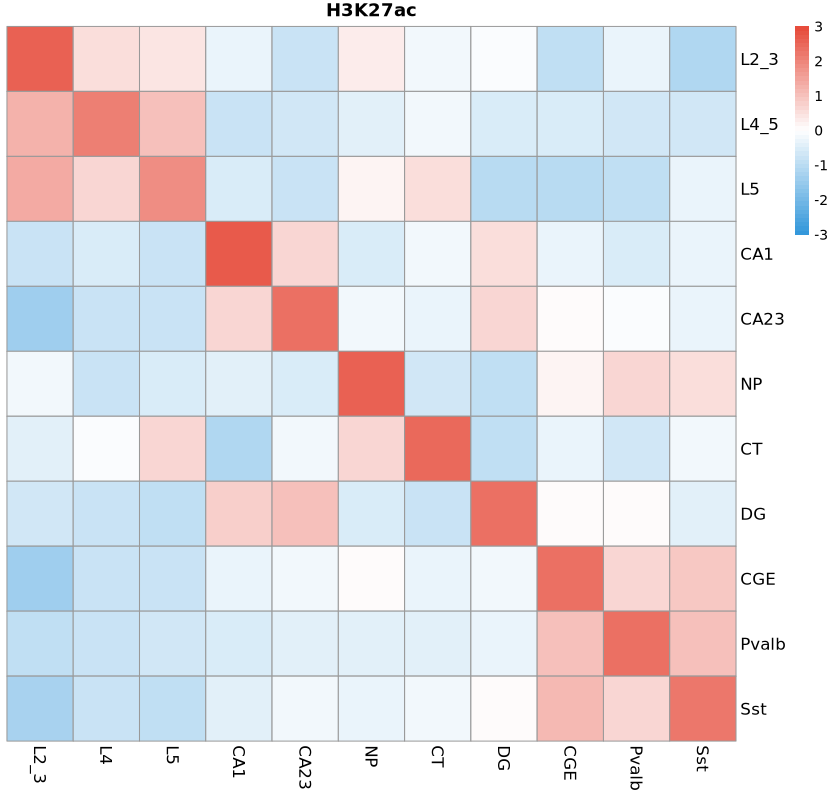

In [58]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27ac",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-3, 3, length.out = 51)
)

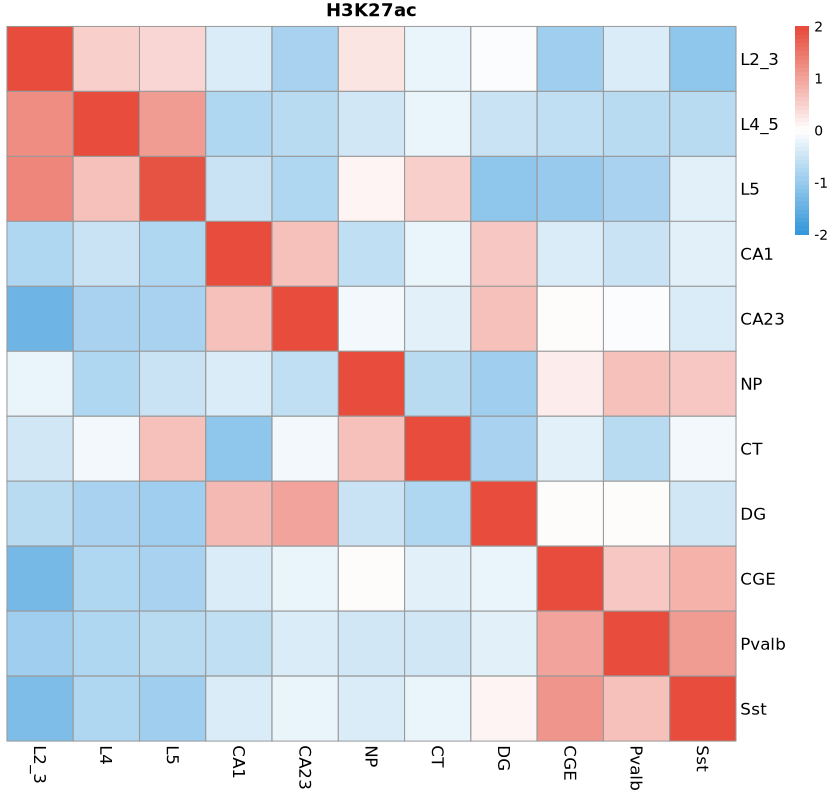

In [59]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27ac",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-2, 2, length.out = 51)
)

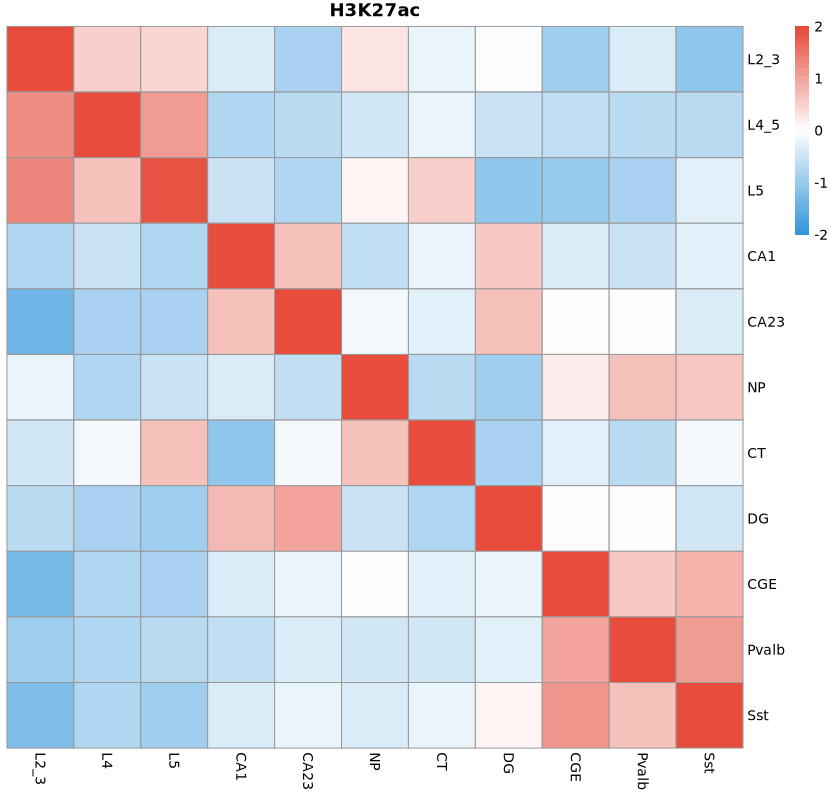

In [60]:
p1 <- pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27ac",
  fontsize_row = 10,
  fontsize_col = 10,
  breaks = seq(-2, 2, length.out = 51)
)

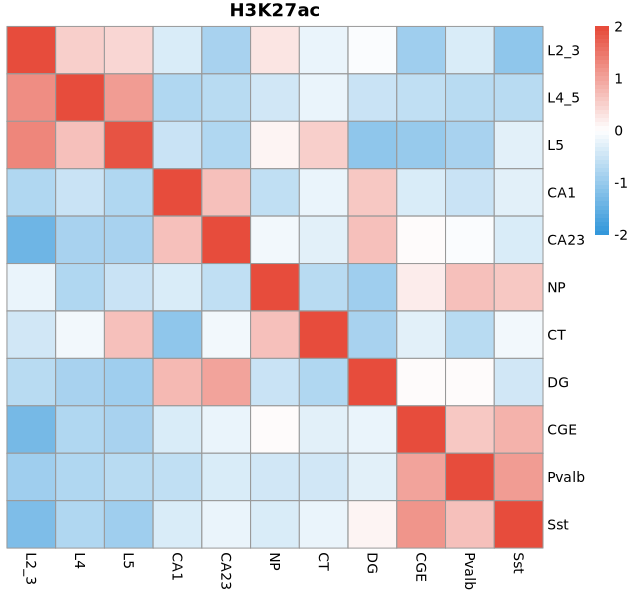

In [61]:
options(repr.plot.width = 6.4, repr.plot.height = 6, repr.plot.res = 100)
p1

In [ ]:
pdf("../../../output/01-youth/07-Histone/01-heatmap/11-H3K27ac_modification_in_hyperDHMR_merge_v3.pdf",width = 6.4,height = 6)
p1
dev.off()

png 
  2

In [ ]:
# Finished!